            term  count
9       concrete    322
42     structure    153
43    structures    151
3      brutalist    121
34          play    105
11      cultural    103
30       natural    100
4          built     93
2      brutalism     89
10  contemporary     85
25          like     85
32      pavilion     84
18          hall     77
24         light     76
26         local     74
0           area     72
49          year     72
6       children     71
21     landscape     69
46          wood     69


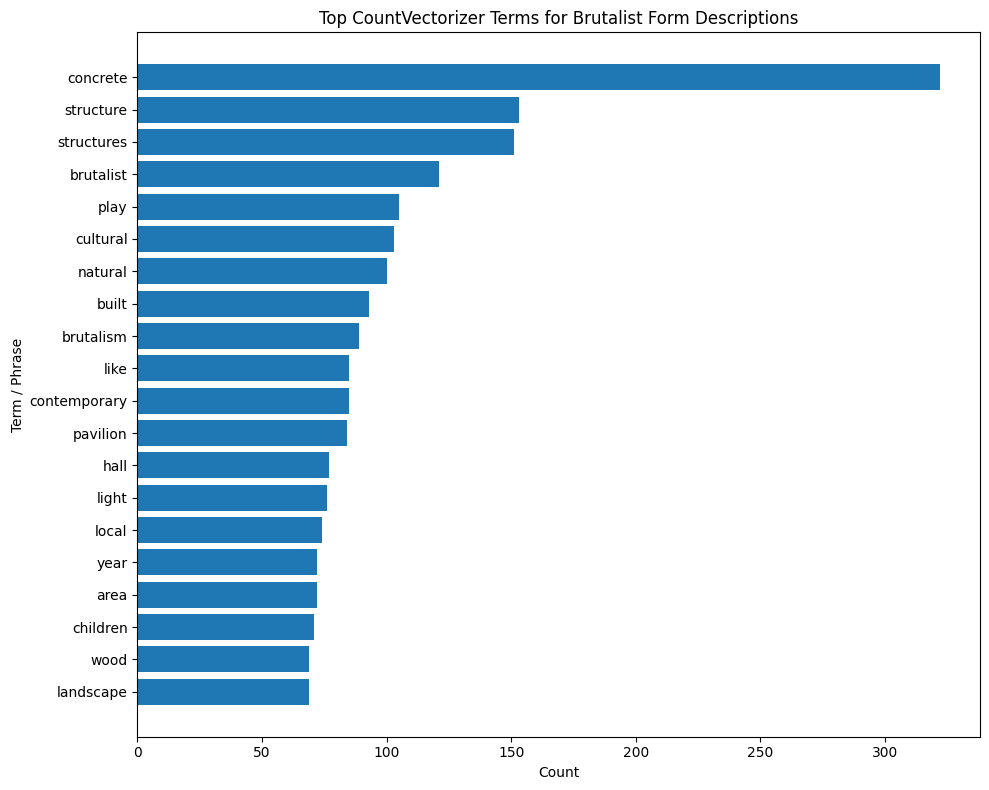

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# 1. 读取 CSV
df = pd.read_csv(r"C:\Users\LZT\Downloads\brutalism_dataset_200\brutalism_architecture_dataset.csv")

# 2. 取 form_text
texts = df["form_text"].dropna().astype(str).tolist()

# 3. 自定义停用词
custom_stop_words = {
    "architecture", "architect", "architects", "architectural",
    "project", "projects", "design", "designed", "designer", "designers",
    "studio", "building", "buildings", "house", "home", "homes",
    "interior", "interiors", "space", "spaces", "room", "rooms",
    "dezeen", "archdaily", "said", "says", "according", "including",
    "features", "feature", "create", "creates", "created", "use", "used",
    "new", "also", "one", "two", "three", "city", "public", "construction",
    "modern", "work", "time", "known", "open", "urban", "materials",
    "material", "form", "forms"
}

all_stop_words = ENGLISH_STOP_WORDS.union(custom_stop_words)

# 4. CountVectorizer
vectorizer = CountVectorizer(
    stop_words=list(all_stop_words),
    max_features=50,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    lowercase=True
)

X = vectorizer.fit_transform(texts)

# 5. 提取词和总频次
words = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

count_df = pd.DataFrame({
    "term": words,
    "count": counts
}).sort_values(by="count", ascending=False)

# 6. 看前 20 个
print(count_df.head(20))

# 7. 画图
top20 = count_df.head(20).sort_values(by="count", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top20["term"], top20["count"])
plt.title("Top CountVectorizer Terms for Brutalist Form Descriptions")
plt.xlabel("Count")
plt.ylabel("Term / Phrase")
plt.tight_layout()
plt.show()
